<a href="https://colab.research.google.com/github/efradotimo-cell/chlorofylo/blob/main/AI_SIEGA_CUP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/datasetaisiega.zip'
extract_path = '/content/garbage_data'

if os.path.exists(zip_path):
    print("Mengekstrak dataset... mohon tunggu.")
    shutil.unpack_archive(zip_path, extract_path)
    print("Ekstrak Selesai!")

    print("Daftar Folder:", os.listdir(extract_path + '/Garbage_Dataset_Classification'))
else:
    print("File ZIP tidak ditemukan. Cek lagi di Drive kamu!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengekstrak dataset... mohon tunggu.
Ekstrak Selesai!
Daftar Folder: ['metadata.csv', 'images']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = '/content/garbage_data/Garbage_Dataset_Classification/images'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)



Found 11123 images belonging to 6 classes.
Found 2778 images belonging to 6 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model siap dilatih!")

Model siap dilatih!


In [ ]:

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


model.save('model_siega_efrado.h5')
print("Training selesai! File 'model_siega_efrado.h5' sudah siap")

Epoch 1/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 516ms/step - accuracy: 0.8654 - loss: 0.3703 - val_accuracy: 0.8639 - val_loss: 0.4053
Epoch 2/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 514ms/step - accuracy: 0.8783 - loss: 0.3278 - val_accuracy: 0.8661 - val_loss: 0.4098
Epoch 3/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 178s 512ms/step - accuracy: 0.8862 - loss: 0.3084 - val_accuracy: 0.8762 - val_loss: 0.3894
Epoch 4/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 180s 518ms/step - accuracy: 0.8937 - loss: 0.2889 - val_accuracy: 0.8880 - val_loss: 0.3645
Epoch 5/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 180s 518ms/step - accuracy: 0.9087 - loss: 0.2520 - val_accuracy: 0.9028 - val_loss: 0.3195
Epoch 6/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 184s 529ms/step - accuracy: 0.9106 - loss: 0.2427 - val_accuracy: 0.8920 - val_loss: 0.3244
Epoch 7/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 515ms/step - accuracy: 0.9189 - loss: 0.2216 - val_accuracy: 0.9032 - val_loss: 0.3044
Epoch 8/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 181s 521ms/step - accuracy: 0.9168 -

Training selesai! File 'model_siega_efrado.h5' sudah siap


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


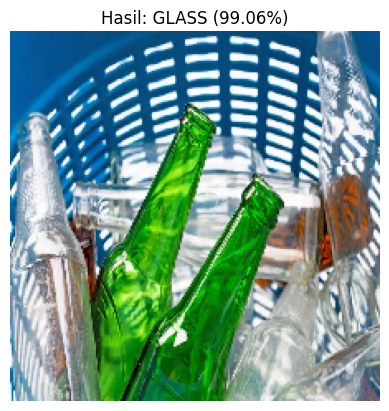

--- ANALISIS AI ---
Kategori: GLASS
Tips Daur Ulang: Pastikan tidak pecah. Bilas bersih. Botol kaca bisa didaur ulang tanpa batas waktu!


In [ ]:
#sebagai template demo, ganti di img_path yang bertuliskan tes_sampah.jpg jadi nama file gambar yang kalian miliki
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = 'sampahkaca.jpg'

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

preds = model.predict(x)
labels = {v: k for k, v in train_gen.class_indices.items()}
hasil = labels[np.argmax(preds)]
confidence = np.max(preds) * 100

tips = {
    "plastic": "Bersihkan dari sisa cairan, lepaskan label, dan keringkan sebelum masuk ke bin daur ulang.",
    "glass": "Pastikan tidak pecah. Bilas bersih. Botol kaca bisa didaur ulang tanpa batas waktu!",
    "metal": "Remas kaleng aluminium untuk menghemat ruang. Pastikan tidak ada sisa makanan di dalamnya.",
    "paper": "Pastikan kertas tidak berminyak (seperti bekas pizza). Lipat rapi agar mudah diproses.",
    "cardboard": "Lepaskan sisa selotip, gepengkan kardus agar efisien saat pengangkutan.",
    "trash": "Ini sampah residu. Buang ke TPA, pastikan dibungkus rapi agar tidak tercecer."
}

rekomendasi = tips.get(hasil, "Kategorikan sampah dengan benar.")

plt.imshow(img)
plt.title(f"Hasil: {hasil.upper()} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"--- ANALISIS AI ---")
print(f"Kategori: {hasil.upper()}")
print(f"Tips Daur Ulang: {rekomendasi}")